In [1]:
# Load packages
suppressPackageStartupMessages({
    library(Seurat)
    library(scran)
    library(scater)
    library(batchelor)
    library(SingleCellExperiment)
    library(scater)
    library(Matrix)
    library(reshape2)
    library(data.table)
    library(BiocParallel)
    library(dplyr)
    library(gridExtra)
})

    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/XXX_test/"
out_dir = paste0(main, '07_atlas_mapping/')
plot_dir = paste0(main, '07_atlas_mapping/plots/')
dir.create(out_dir, showWarnings = FALSE)
dir.create(plot_dir, showWarnings = FALSE)

source(paste0(main, "mapping_functions.R"))

In [3]:
load_data(normalise=TRUE)
sce_query = sce[Matrix::rowSums(counts(sce)) > 0,]
meta_query = meta

In [4]:
load_atlas_data(normalise=FALSE)
sce_atlas = sce[Matrix::rowSums(counts(sce)) > 0,]
meta_atlas = meta

In [5]:
# genes shared across datasets
shared_genes = merge(data.frame('V1'=names(sce_atlas)), data.frame('V1'=names(sce_query)), by='V1')

# filter cells & genes chimera dataset
sce_query = sce_query[shared_genes$V1,!c(meta_query$doublet | meta_query$stripped)]
meta_query = meta_query[!c(meta_query$doublet | meta_query$stripped),]

# filter cells & genes atlas dataset
sce_atlas = sce_atlas[shared_genes$V1,!c(meta_atlas$doublet | meta_atlas$stripped)]
meta_atlas = meta_atlas[!c(meta_atlas$doublet | meta_atlas$stripped),]

In [6]:
#Downsample to 10k cells per sample (or maximum number of cells in sample)
set.seed(42)
keep = lapply(unique(meta_atlas$stage), function(x){
  if(x == "mixed_gastrulation"){
    return(c())
  } else if(sum(meta_atlas$stage == x) < 10000) {
    return(which(meta_atlas$stage == x))
  } else {
    hits = which(meta_atlas$stage == x)
    return(sample(hits, 10000))
  }
})
keep = do.call(c, keep)

sce_atlas = logNormCounts(sce_atlas[,keep])
meta_atlas = meta_atlas[keep,]

In [12]:
mappings = mapWrap(
        atlas_sce = sce_atlas, 
        atlas_meta = meta_atlas,
        map_sce = sce_query, 
        map_meta = meta_query, 
        # genes = marker_genes, 
        npcs = 50, 
        k = 30)$mapping

Normalizing joint dataset...

Done


Genes not provided. Computing highly variable genes...

Done


Performing PCA...

Done


Batch effect correction for the atlas...

Done


MNN mapping...

Done


Computing mapping scores...

Done


Writing output...

Done




In [13]:
umap_theme =  theme(text = element_text(size = 30),
                axis.text.y   = element_blank(),
                axis.text.x   = element_blank(),
                axis.title.y  = element_blank(),
                axis.title.x  = element_blank(),
                axis.ticks = element_blank(),
                legend.position = "none",
                panel.background = element_blank(),
                panel.grid.major = element_blank(), 
                panel.grid.minor = element_blank(),
                panel.border = element_rect(colour = "black", fill=NA, size=1))

In [14]:
head(mappings)

,cell,celltype.mapped,stage.mapped,closest.cell,celltype.score,cellstage.score
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
cell_1,cell_1,Rostral neurectoderm,E8.0,cell_18329,0.9333333,0.5000000
cell_2,cell_2,Intermediate mesoderm,E8.0,cell_35709,1.0000000,0.5666667
cell_3,cell_3,Allantois,E8.25,cell_101085,0.7000000,0.5333333
cell_4,cell_4,Surface ectoderm,E8.25,cell_123113,0.7333333,0.4666667
cell_6,cell_6,Caudal Mesoderm,E8.0,cell_116088,0.9000000,0.5666667
cell_7,cell_7,Intermediate mesoderm,E8.0,cell_70126,0.8666667,0.6000000


In [15]:
atlas_meta = meta_atlas
atlas_umap <- atlas_meta[, c('cell', 'umapX', 'umapY')]
mappings = merge(mappings, atlas_umap, by.x='closest.cell', by.y='cell')

query_tdtom = meta_query[, c('cell', 'tdTom')]
mappings = merge(mappings, query_tdtom, by='cell')

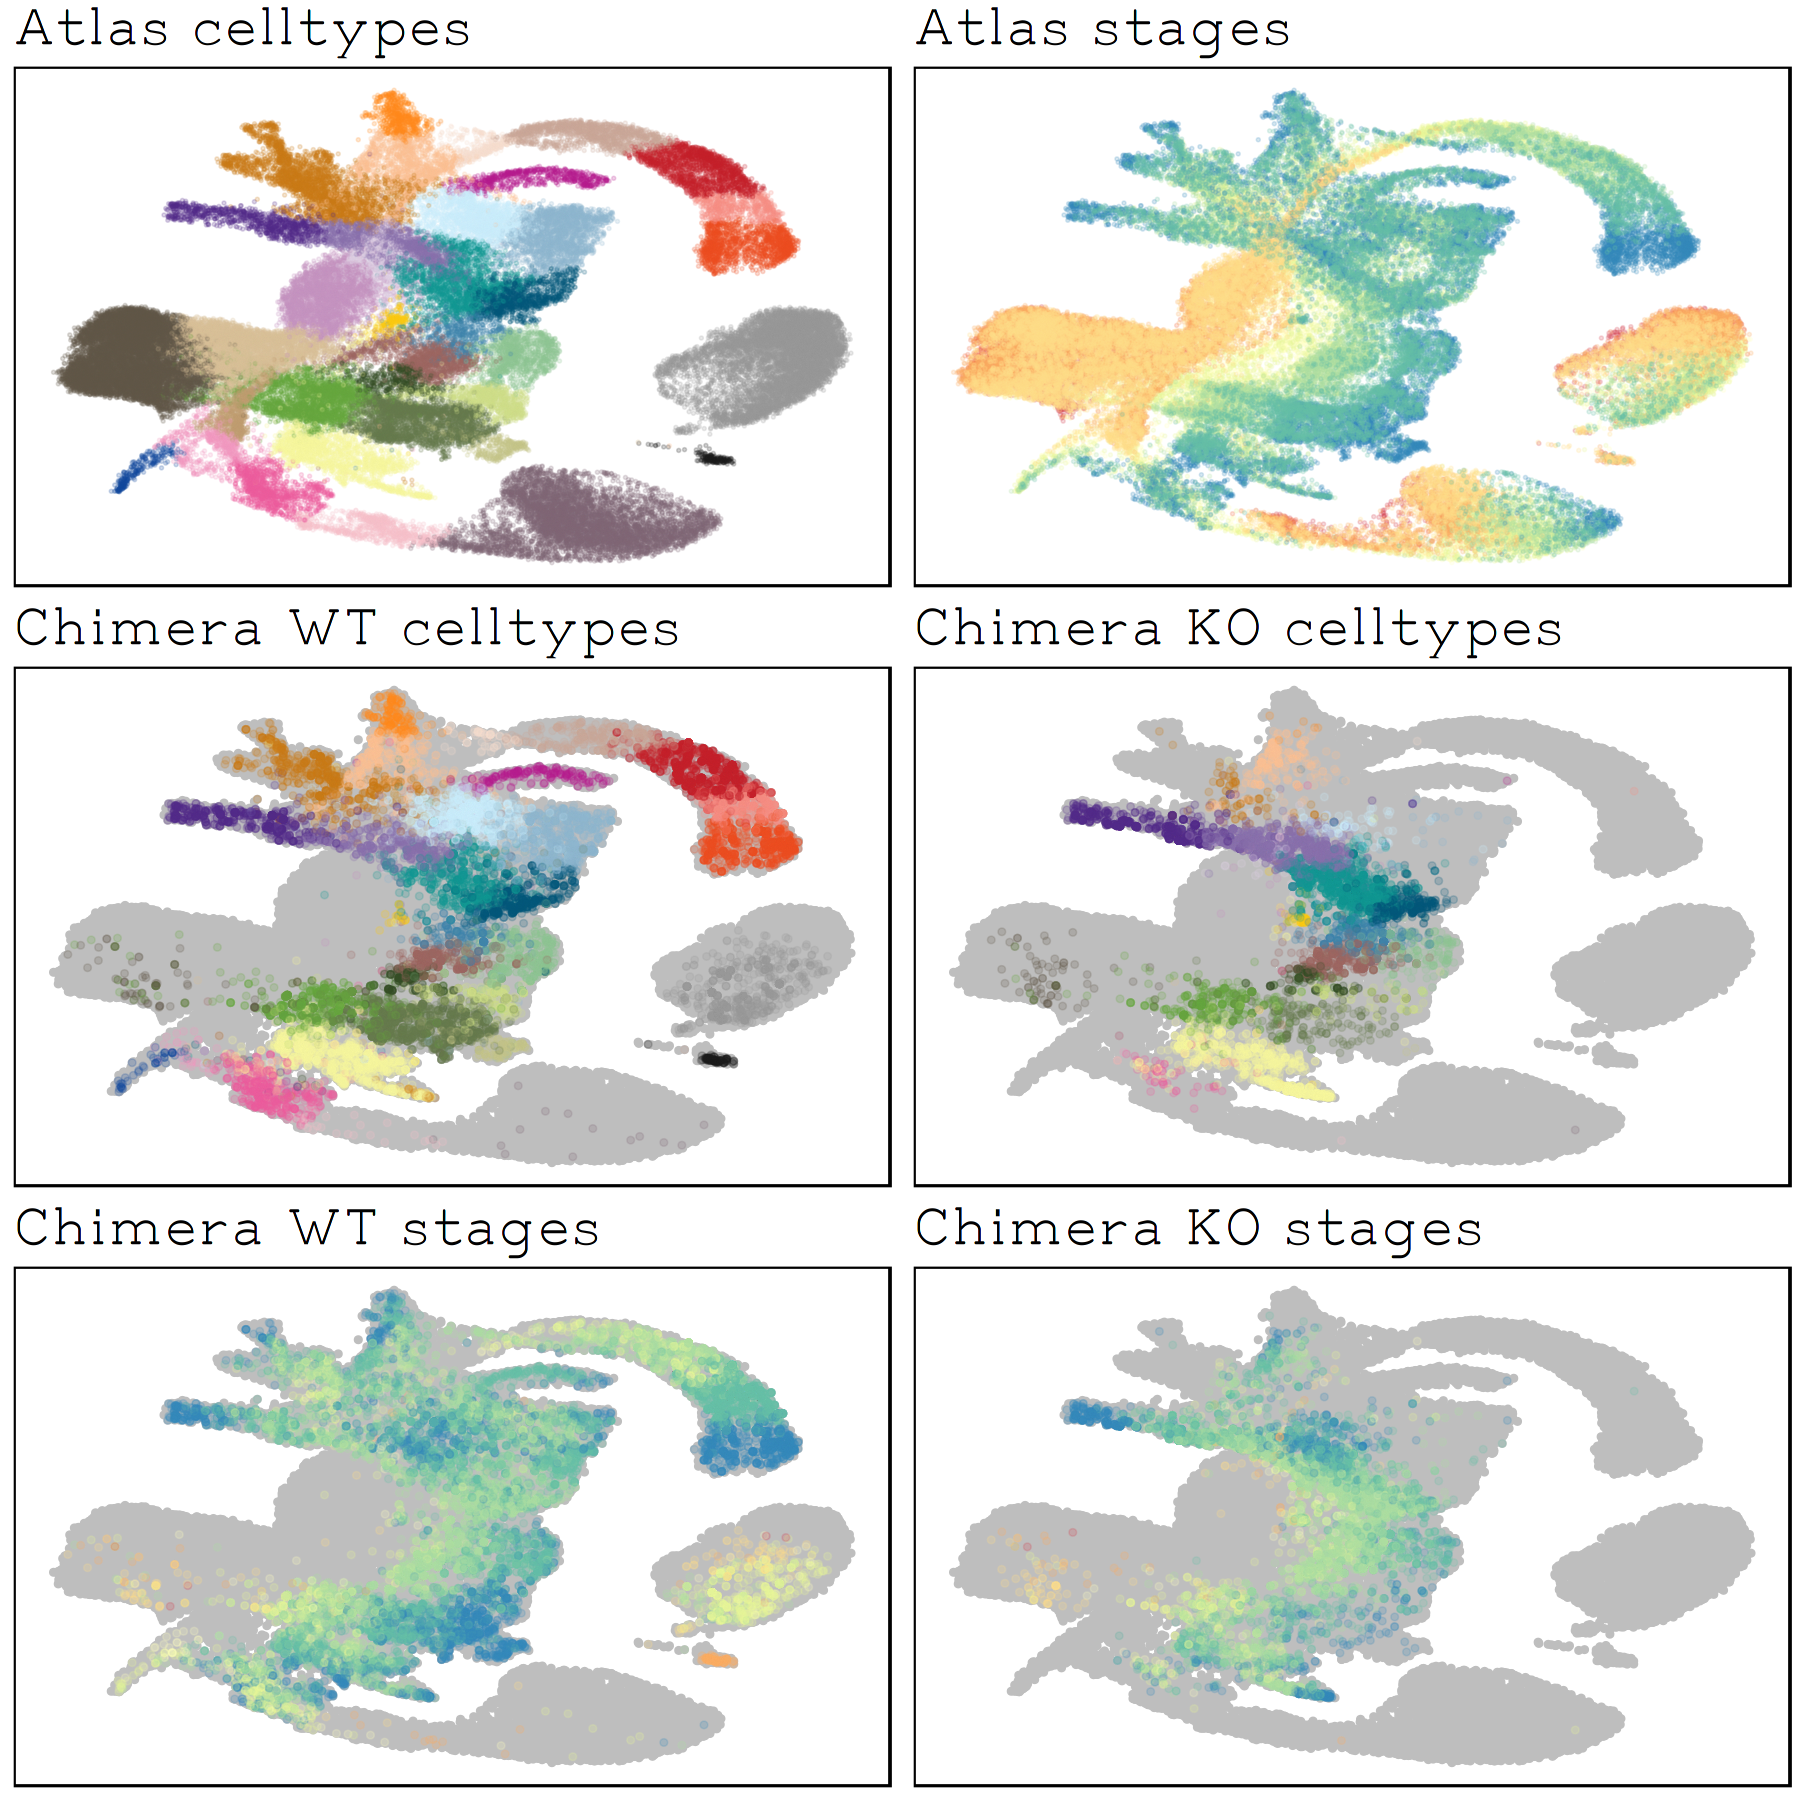

In [16]:
p1 = ggplot(atlas_meta, aes(umapX, umapY, col=celltype)) + 
    geom_point(alpha=0.2, size = 0.5) + 
    ggtitle('Atlas celltypes') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p2 = ggplot(atlas_meta, aes(umapX, umapY, col=stage)) + 
    geom_point(alpha=0.2, size = 0.5) + 
    ggtitle('Atlas stages') + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    umap_theme

p3 = ggplot(mappings[mappings$tdTom=='negative',], aes(umapX, umapY, col=mappings[mappings$tdTom=='negative',]$celltype.mapped)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera WT celltypes') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p4 = ggplot(mappings[mappings$tdTom=='positive',], aes(umapX, umapY, col=mappings[mappings$tdTom=='positive',]$celltype.mapped)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera KO celltypes') + 
    scale_colour_manual(values = celltype_colours, name = "celltype") +
    umap_theme

p5 = ggplot(mappings[mappings$tdTom=='negative',], aes(umapX, umapY, col=mappings[mappings$tdTom=='negative',]$stage.mapped)) + 
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera WT stages') + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    umap_theme

p6 = ggplot(mappings[mappings$tdTom=='positive',], aes(umapX, umapY, col=mappings[mappings$tdTom=='positive',]$stage.mapped)) +
    geom_point(data=atlas_meta, aes(umapX, umapY), col='grey') + 
    geom_point(alpha=0.2) + 
    ggtitle('Chimera KO stages') + 
    scale_colour_manual(values = stage_colours, name = "Stage") +
    umap_theme

options(repr.plot.width=15, repr.plot.height=15)
grid.arrange(p1, p2, p3, p4, p5, p6, ncol=2)

In [ ]:
# add plots for mapping scores!!

In [ ]:
ggsave(paste0(plot_dir, 'Atlas_projection.png'), 
       plot = grid.arrange(p1, p2, p3, p4, p5, p6, ncol=2), 
       device = 'png',
       width = 12,
       height = 15,
       dpi = 300)